In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.cluster.hierarchy import dendrogram
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_hex
import pandas as pd

#color_df = pd.read_csv("cluster_to_color.csv")
#cluster_to_color = dict(zip(color_df["Cluster"].astype(str), color_df["Color"]))

# Load MATLAB linkage matrix
Z = np.loadtxt(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\042126_m2_dls_cluster_output_saline+inhibition\Combined_Results\Results\test1\linkage_matlab.csv", delimiter=",")

threshold = Z[0,0]
Z = Z[1:,:]
def add_sample_counts(Z):
    """
    Add the 4th column (cluster sizes) required by SciPy dendrogram.
    Assumes Z is (n-1, 3) with 0-based indices.
    """
    Z = Z.copy()
    n = Z.shape[0] + 1

    counts = np.zeros(Z.shape[0], dtype=int)

    for i in range(Z.shape[0]):
        c1, c2 = int(Z[i, 0]), int(Z[i, 1])

        def cluster_size(c):
            if c < n:
                return 1
            else:
                return counts[c - n]

        counts[i] = cluster_size(c1) + cluster_size(c2)

    return np.column_stack([Z, counts])


# Convert MATLAB (1-based) → Python (0-based)
Z[:, 0:2] -= 1

# Add 4th column
Z = add_sample_counts(Z)

In [21]:
df = pd.read_csv(r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\042126_m2_dls_cluster_output_saline+inhibition\Combined_Results\Results\test1\combined_results_dls_with_features.csv")

Z_levels = Z.copy()
max_distance = np.max(Z[:, 2])
custom_thresholds = np.linspace(threshold, max_distance*0.5, 4, endpoint=False)
custom_thresholds = np.sort(custom_thresholds)

# Assign each merge to a level 1–5 based on custom thresholds
for i in range(Z_levels.shape[0]):
    dist = Z_levels[i, 2]
    level = np.sum(dist > custom_thresholds) + 1  # level from 1 to 5
    Z_levels[i, 2] = level

n = Z.shape[0] + 1
leaf_labels = np.arange(1, n+1)

In [22]:
df

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature29,Feature30,Timestamp,Cluster,Week_Number,Group,anterior_posterior_x_accel,dorsal_ventral_y_accel,y_gyro,TotAccelBA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.083333,0.483333,0.400000,...,0.116667,0.883333,686.4304,1.0,1,6,0.753755,-0.696290,-29.662832,0.119560
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.083333,0.300000,0.500000,...,0.066667,0.933333,686.7302,1.0,1,6,0.806058,-0.584729,9.950256,0.160500
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.100000,0.216667,0.150000,...,0.000000,1.000000,687.0299,1.0,1,6,1.001962,-0.075360,-3.897095,0.358540
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.250000,0.033333,...,0.000000,1.000000,687.3296,1.0,1,6,1.006182,0.016323,0.724284,0.390317
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.066667,0.466667,...,0.000000,1.000000,687.6294,1.0,1,6,1.011023,0.023201,9.673055,0.424227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.466667,0.416667,...,0.000000,1.000000,10580.4977,9.0,2,2,0.826711,0.354163,4.984029,0.151631
29697,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.233333,0.633333,0.133333,...,0.083333,0.916667,10580.8427,41.0,2,14,0.630483,0.757597,-4.715983,0.108281
29698,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.350000,0.333333,0.083333,...,0.000000,1.000000,10581.1877,8.0,2,15,0.711389,0.706714,54.988098,0.299210
29699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133333,0.133333,0.366667,...,0.000000,1.000000,10581.5377,28.0,2,13,0.882521,-0.261916,45.122274,0.203042


In [23]:
def get_dendogram_color_data(dendrogram_data, all_segments, final_colors):
    leaf_order = dendrogram_data['leaves']
    leaf_x_positions = []
    leaf_colors = []

    for seg, color in zip(all_segments, final_colors):
        if np.any(np.isclose(seg[:, 1], 0)):
            bottom_points = seg[np.isclose(seg[:, 1], 0)]
            for pt in bottom_points:
                leaf_x_positions.append(pt[0])
                leaf_colors.append(color)

    leaf_x_positions = np.array(leaf_x_positions)
    leaf_colors = np.array(leaf_colors)

    unique_x, unique_indices = np.unique(leaf_x_positions, return_index=True)
    leaf_x_positions = unique_x
    leaf_colors = leaf_colors[unique_indices]

    sort_idx = np.argsort(leaf_x_positions)
    leaf_x_positions = leaf_x_positions[sort_idx]
    leaf_colors = leaf_colors[sort_idx]

    df_leaf_colors = pd.DataFrame({
        "LeafIndex": leaf_order,
        "ClusterLabel": df['Cluster'].values[leaf_order],
        "XPosition": leaf_x_positions,
        "RGBA_Color": list(leaf_colors)
    })

    df_leaf_colors["HEX_Color"] = df_leaf_colors["RGBA_Color"].apply(to_hex)
    return df_leaf_colors

In [24]:
stages = []
# week_numbers = df["Week_Number"].unique()
# week_numbers.sort()

# for week in week_numbers:
#     week_data = df[df["Week_Number"] == week ]
#     stages.append(week_data)


week_data = df[(df["Week_Number"] == 1)]
stages.append(week_data)
week_data = df[(df["Week_Number"] == 2)]
stages.append(week_data)

In [25]:
week_data

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature29,Feature30,Timestamp,Cluster,Week_Number,Group,anterior_posterior_x_accel,dorsal_ventral_y_accel,y_gyro,TotAccelBA
11966,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.033333,0.466667,0.066667,...,0.000000,1.000000,4286.4977,26.0,2,2,0.873418,0.304299,-0.730387,0.283212
11967,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.016667,0.166667,0.816667,...,0.000000,1.000000,4286.8777,26.0,2,2,0.862549,0.316512,-24.403890,0.116103
11968,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.066667,0.133333,0.766667,...,0.000000,1.000000,4287.2227,28.0,2,13,0.849722,-0.289319,17.887878,0.207638
11969,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.900000,...,0.016667,0.983333,4287.5677,7.0,2,13,0.897246,-0.288495,16.690572,0.273616
11970,0.0,0.0,0.0,0.0,0.0,0.0,0.016667,0.016667,0.333333,0.166667,...,0.000000,1.000000,4287.9277,4.0,2,13,0.912253,-0.275291,-78.148397,0.321679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29696,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.466667,0.416667,...,0.000000,1.000000,10580.4977,9.0,2,2,0.826711,0.354163,4.984029,0.151631
29697,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.233333,0.633333,0.133333,...,0.083333,0.916667,10580.8427,41.0,2,14,0.630483,0.757597,-4.715983,0.108281
29698,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.350000,0.333333,0.083333,...,0.000000,1.000000,10581.1877,8.0,2,15,0.711389,0.706714,54.988098,0.299210
29699,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.133333,0.133333,0.366667,...,0.000000,1.000000,10581.5377,28.0,2,13,0.882521,-0.261916,45.122274,0.203042


In [26]:
def dendogram_plot_combined_stages(save_path, stages, fixed_max=None):
    """
    Plot one dendrogram with 5 bar graphs (one per stage) stacked below it.
    All bar graphs share the same x-axis aligned to dendrogram leaves.
    Bars exceeding fixed_max are clipped and annotated with their actual value.
    """
    n_stages = len(stages)

    height_ratios = [4] + [1.2] * n_stages
    fig, axes = plt.subplots(
        n_stages + 1, 1,
        figsize=(18, 4 + n_stages * 1.8),
        gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.05},
        sharex=True
    )

    ax_dendro = axes[0]
    ax_bars = axes[1:]

    # -------------------------
    # DENDROGRAM
    # -------------------------
    ddata = dendrogram(Z_levels, ax=ax_dendro, labels=leaf_labels)

    line_collections = [c for c in ax_dendro.collections if isinstance(c, LineCollection)]

    all_segments = []
    segment_map = []
    for lc in line_collections:
        for seg in lc.get_segments():
            all_segments.append(seg)
            segment_map.append(lc)

    vertical_indices = []
    vertical_x = []
    for i, seg in enumerate(all_segments):
        if np.allclose(seg[0, 0], seg[1, 0]):
            vertical_indices.append(i)
            vertical_x.append(seg[0, 0])

    vertical_x = np.array(vertical_x)
    x_min, x_max = vertical_x.min(), vertical_x.max()
    x_norm = (vertical_x - x_min) / (x_max - x_min)

    cmap = LinearSegmentedColormap.from_list(
        "custom_gradient",
        ["#eec42b", "#61b751", "#2a84df", "#dd077a"]
    )

    final_colors = [(0.7, 0.7, 0.7, 1)] * len(all_segments)
    for idx, norm_val in zip(vertical_indices, x_norm):
        final_colors[idx] = cmap(norm_val)

    start = 0
    for lc in line_collections:
        lc.set_linewidth(2)
        seg_count = len(lc.get_segments())
        lc.set_color(final_colors[start:start + seg_count])
        start += seg_count

    ax_dendro.spines['bottom'].set_visible(False)
    ax_dendro.set_ylabel("Hierarchy Level")
    ax_dendro.set_yticks(range(1, 6))
    ax_dendro.set_yticklabels(list(range(5, 0, -1)))
    ax_dendro.set_title("5-Level Hierarchy Dendrogram — All Stages")
    ax_dendro.tick_params(axis='x', length=0, labelsize=6)

    df_leaf_colors = get_dendogram_color_data(ddata, all_segments, final_colors)
    bar_colors = df_leaf_colors["RGBA_Color"].tolist()

    leaf_order = ddata['leaves']
    x_positions = np.arange(len(leaf_order)) * 10 + 5

    # -------------------------
    # BAR GRAPHS — one per stage
    # -------------------------
    global_max = 0
    all_bar_values = []

    for stage_df in stages:
        cluster_counts = stage_df.groupby('Cluster').size()
        cluster_percent = cluster_counts / cluster_counts.sum() * 100
        bar_values = []
        for label in leaf_order:
            cluster_label = label + 1
            bar_values.append(cluster_percent.get(cluster_label, 0))
        all_bar_values.append(bar_values)
        global_max = max(global_max, max(bar_values))

    if fixed_max is not None:
        global_max = fixed_max

    y_limit = global_max * 1.15
    print(f"Global max for bar heights: {global_max:.2f}")

    for i, (ax_bar, bar_values, stage_df) in enumerate(zip(ax_bars, all_bar_values, stages)):
        for x, val, color in zip(x_positions, bar_values, bar_colors):
            if fixed_max is not None and val > fixed_max:
                bar_end = y_limit * 0.85

                # Draw clipped bar
                ax_bar.bar(x, bar_end, width=8, color=color)

                # Draw zigzag break lines at the clipped edge
                bar_half = 3  # half of bar width=8
                zz_amp = 0.3  # zigzag amplitude (in x units)
                zz_y_step = bar_end * 0.06 # zigzag height as fraction of axis

                # Two offset zigzag lines to make a "cut" symbol
                for x_offset in [-bar_half * 0.3, bar_half * 0.3]:
                    zx = [
                        x - bar_half + x_offset,
                        x - bar_half * 0.3 + x_offset + zz_amp,
                        x + bar_half * 0.3 + x_offset - zz_amp,
                        x + bar_half + x_offset
                    ]
                    zy = [
                        bar_end * 0.9 - zz_y_step,
                        bar_end * 0.9 - zz_y_step * 2,
                        bar_end * 0.9 - zz_y_step * 0,
                        bar_end * 0.9 - zz_y_step
                    ]
                    ax_bar.plot(zx, zy, color='white', linewidth=1.2, solid_capstyle='round')

                # Value label
                ax_bar.text(
                    x, bar_end * 1.05,
                    f"{val:.1f}",
                    ha='center', va='top',
                    fontsize=4, fontweight='light', color='black'
                )
            else:
                ax_bar.bar(x, val, width=8, color=color)

        ax_bar.set_ylim(0, y_limit)
        ax_bar.invert_yaxis()
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.spines['bottom'].set_visible(False)
        if i == 0:
            title = "Baseline"
        elif i == 1:
            title = "Inhibition"
        ax_bar.set_ylabel(f"{title}\n(Cluster %)", fontsize=8, rotation=90, labelpad=10, va='center')
        ax_bar.tick_params(axis='x', labelsize=6, rotation=90)
        ax_bar.tick_params(axis='y', labelsize=7)
        ax_bar.yaxis.set_major_locator(plt.MaxNLocator(2, integer=False))

    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    #plt.tight_layout()
    plt.show()
    print(f"Saved to {save_path}")

Global max for bar heights: 5.41


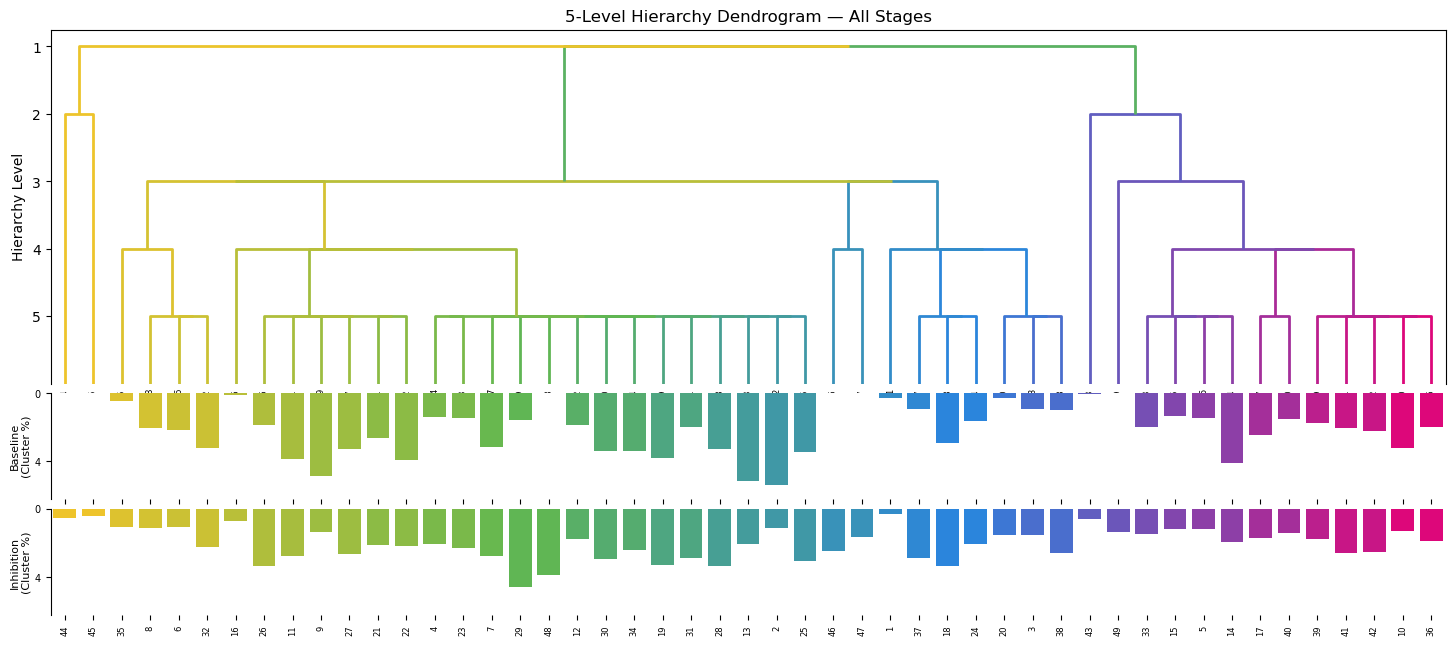

Saved to Hierarchy_Dendogram_Filtered.png
Global max for bar heights: 5.41


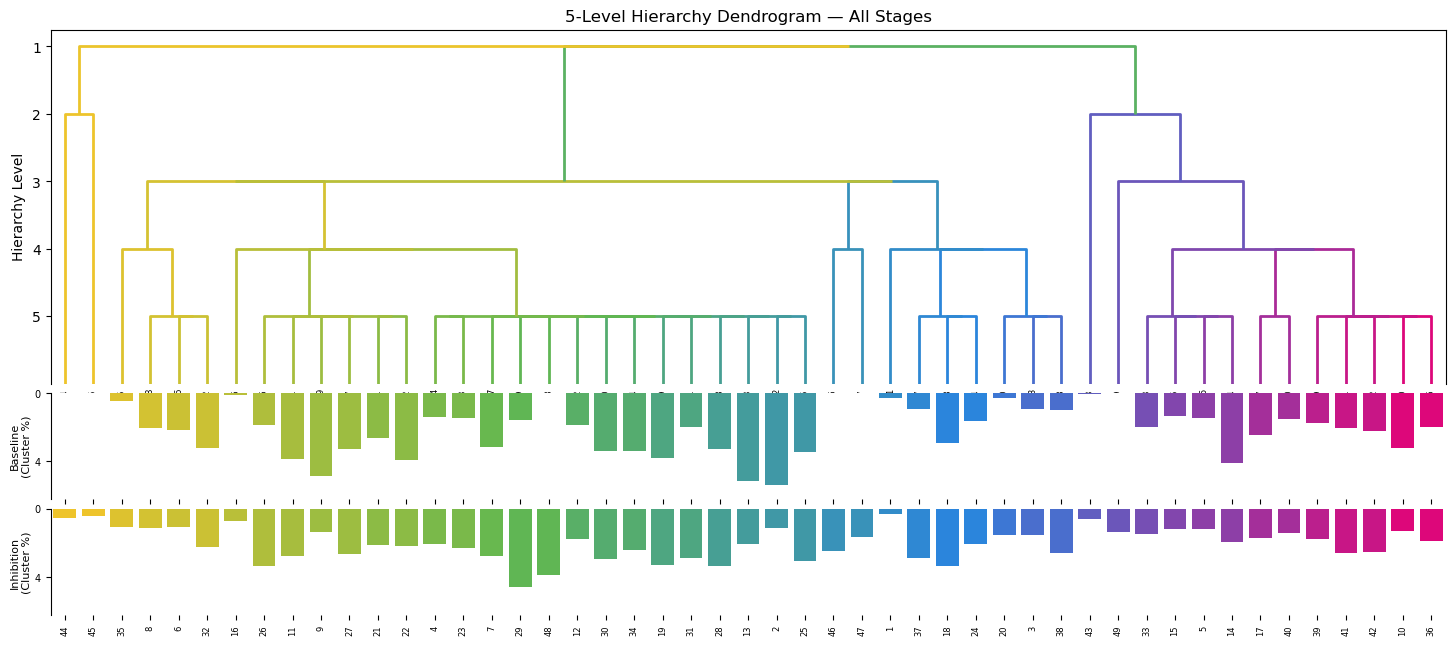

Saved to Hierarchy_Dendogram_Filtered.eps


In [27]:
dendogram_plot_combined_stages("Hierarchy_Dendogram_Filtered.png", stages)
dendogram_plot_combined_stages("Hierarchy_Dendogram_Filtered.eps", stages)

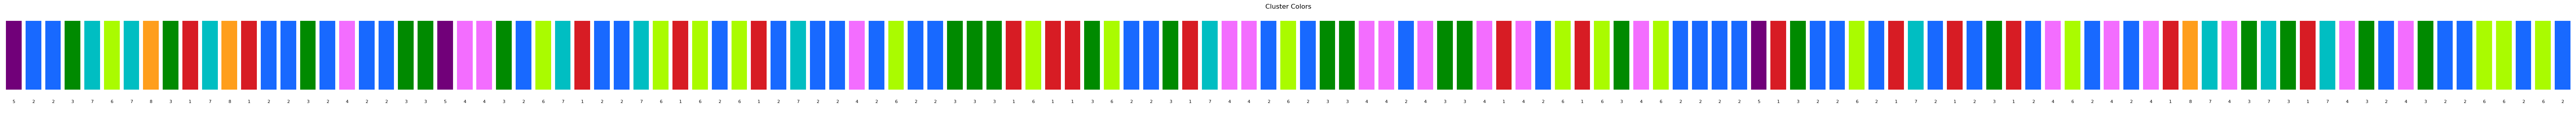

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_df = pd.read_csv("cluster_to_color.csv")
color_df = df_leaf_colors
fig, ax = plt.subplots(figsize=(max(6, len(color_df) * 0.5), 3))

for i, row in color_df.iterrows():
    ax.bar(i, 1, color=row["HEX_Color"], width=0.8)
    ax.text(i, -0.15, str(row["ClusterLabel"]), ha='center', va='top', fontsize=8)

ax.set_xlim(-0.5, len(color_df) - 0.5)
ax.set_ylim(-0.3, 1.1)
ax.axis('off')
ax.set_title("Cluster Colors", fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("cluster_colors.png", dpi=150, bbox_inches='tight')
plt.show()